In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Read the data
Wine_data=pd.read_csv(r'C:\data files for python in data handling\winequality_red.csv')
Wine_data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


- Loaded the dataset into the analysis environment.

- Checked the number of rows and columns.

- Identified the target variable (quality).

- Verified data types of all features.

In [3]:
Wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
Wine_data.shape


(1599, 12)

In [5]:
Wine_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


## check the Null null values

In [6]:
Wine_data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

- There is no null values in the data

In [7]:
Wine_data.duplicated().sum()

np.int64(240)

In [8]:
Wine_data[Wine_data.duplicated(keep=False)]


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
9,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
11,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
22,7.9,0.430,0.21,1.6,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1567,7.2,0.695,0.13,2.0,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1579,6.2,0.560,0.09,1.7,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5
1581,6.2,0.560,0.09,1.7,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5
1592,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6


- Checked for missing values across all columns.

- Verified data completeness and consistency.

- Identified duplicate records in the dataset.

- Ensured all features were numeric and usable.

In [9]:
Wine_data = Wine_data.drop_duplicates()

- Detected exact duplicate rows.

- Analyzed whether duplicates carried meaningful information.

- Removed duplicate rows to avoid biased analysis.

- Revalidated dataset shape after duplicate removal

In [10]:
Wine_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


- Calculated mean, median, standard deviation, minimum, and maximum values.

- Analyzed feature ranges and variability.

- Identified potential anomalies and extreme values.

- Used statistics to support visual findings

## Target Variable Analysis

In [11]:
Wine_data['quality'].value_counts().sort_index()

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

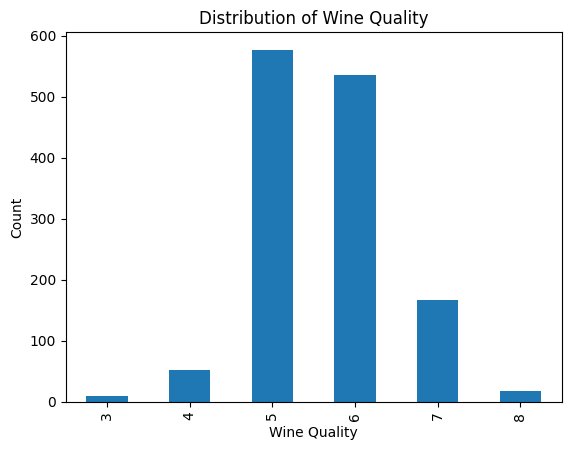

In [12]:
Wine_data['quality'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Wine Quality")
plt.ylabel("Count")
plt.title("Distribution of Wine Quality")
plt.show()

- Analyzed the frequency distribution of quality scores.

- Identified class imbalance in the target variable.

- Evaluated the nature of the target (discrete numeric).

- Used insights to guide modeling strategy.

## Univariate Analysis

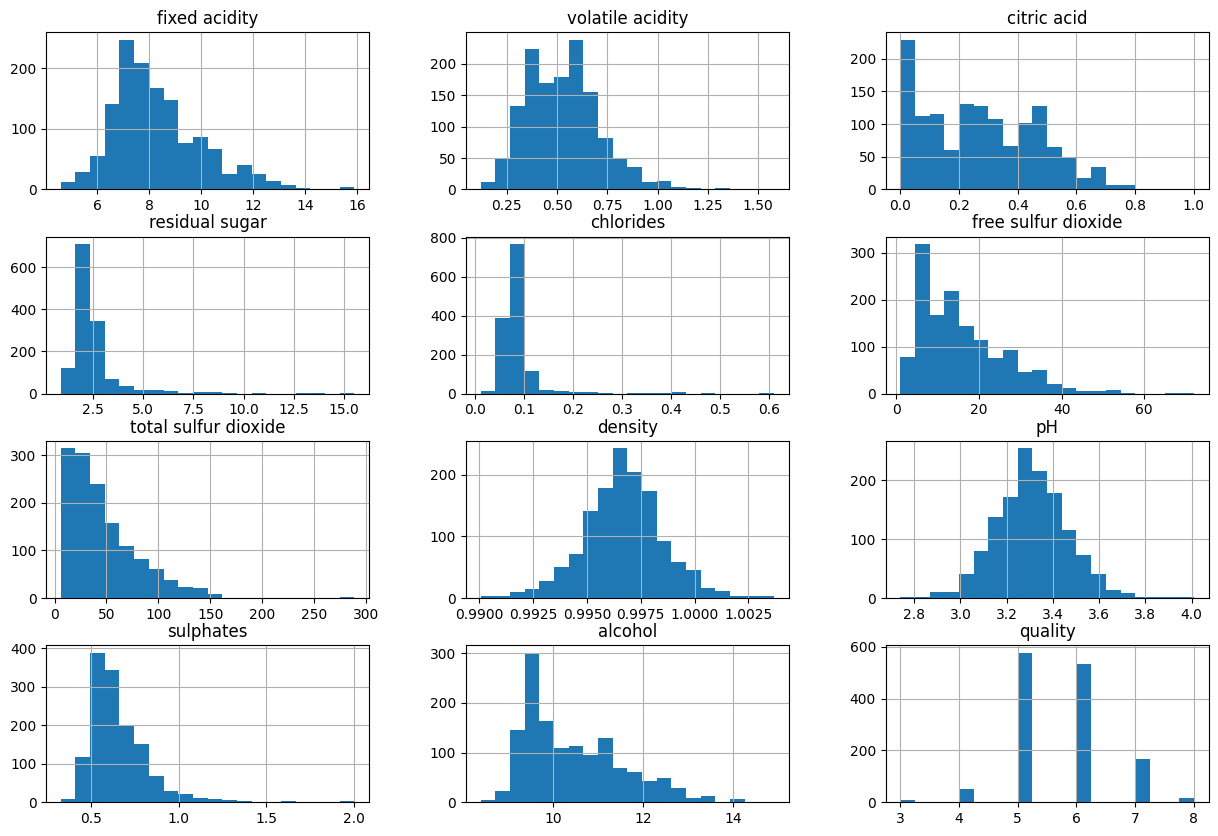

In [14]:
Wine_data.hist(bins=20,figsize=(15,10))
plt.show()

- Visualized distributions using histograms.

- Used boxplots to examine data spread.

- Identified skewed features.

- Highlighted variables requiring transformation.

## Outliers detection

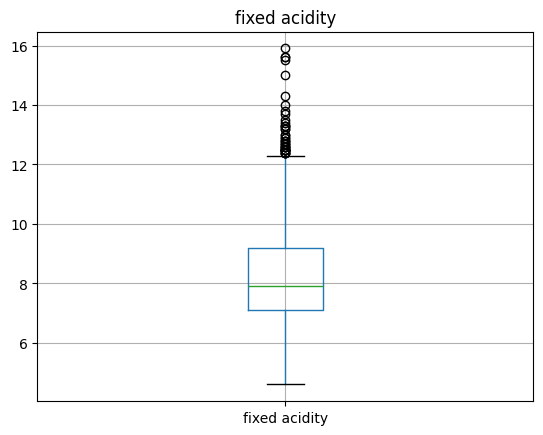

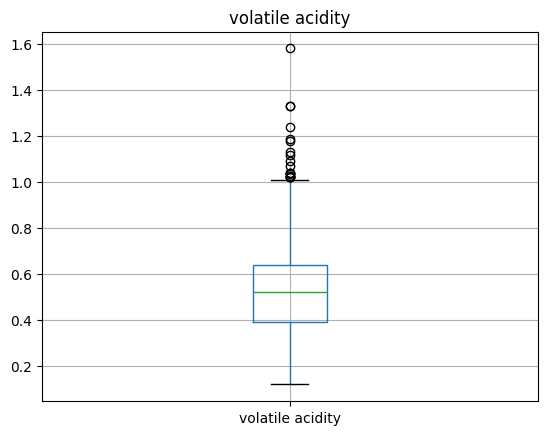

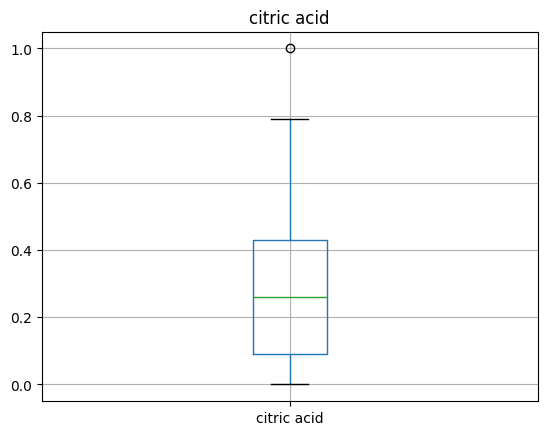

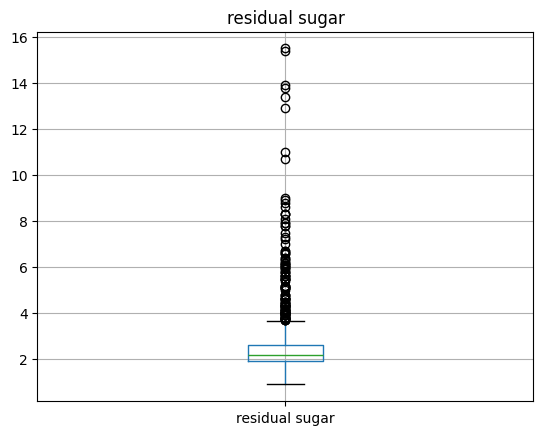

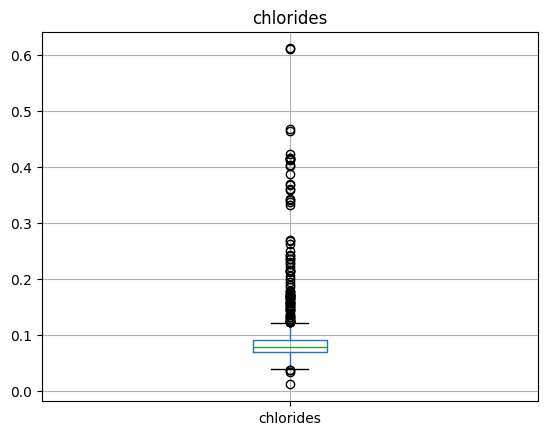

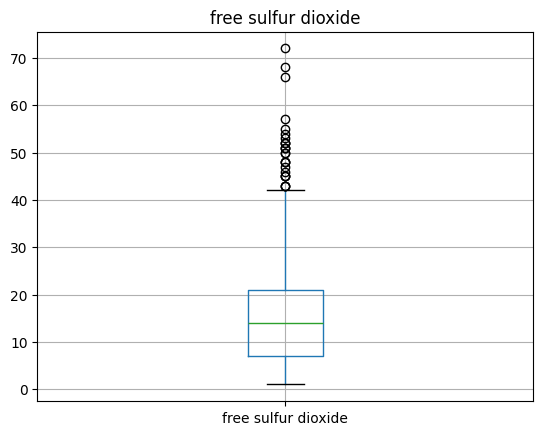

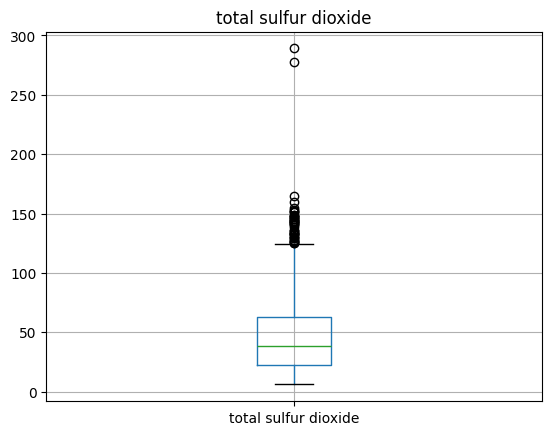

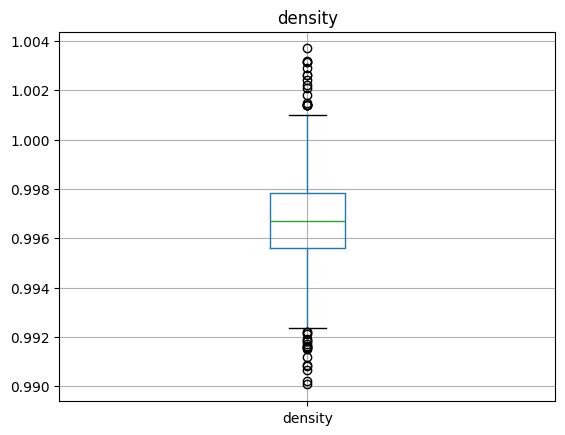

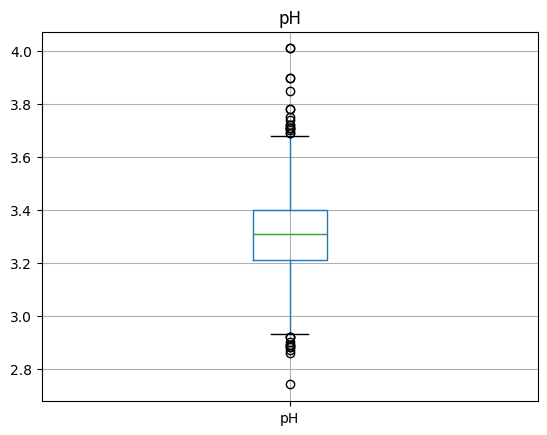

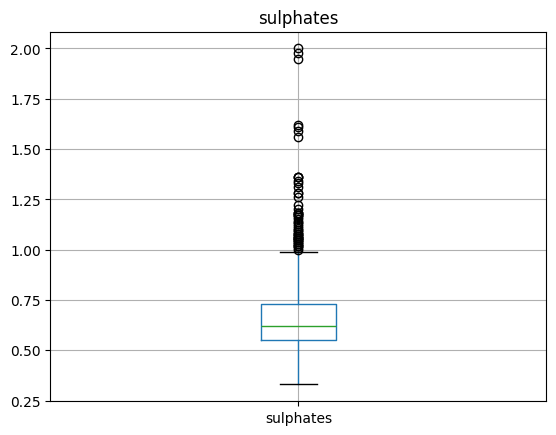

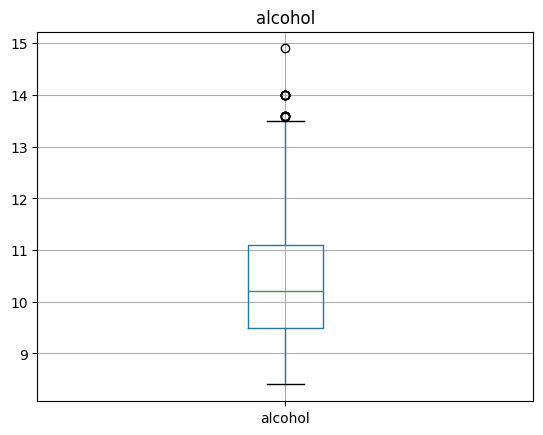

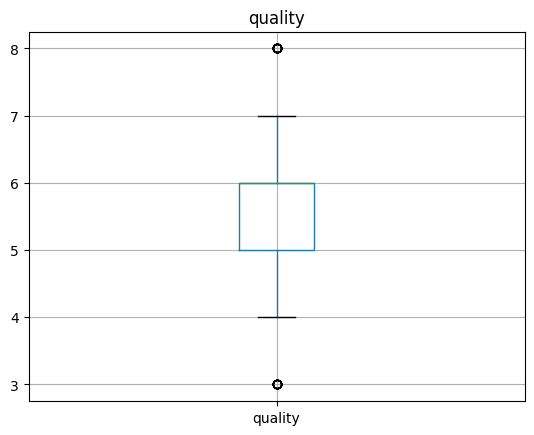

In [15]:
for col in Wine_data.columns:
    plt.figure()
    Wine_data.boxplot(column=col)
    plt.title(col)
    plt.show()


In [16]:
Q1 = Wine_data.quantile(0.25)
Q3 = Wine_data.quantile(0.75)
IQR = Q3 - Q1

outliers = ((Wine_data < (Q1 - 1.5 * IQR)) | (Wine_data > (Q3 + 1.5 * IQR))).sum()
outliers


fixed acidity            41
volatile acidity         19
citric acid               1
residual sugar          126
chlorides                87
free sulfur dioxide      26
total sulfur dioxide     45
density                  35
pH                       28
sulphates                55
alcohol                  12
quality                  27
dtype: int64

- Detected outliers using boxplots and IQR method.

- Evaluated the impact of extreme values.

- Decided whether to retain, transform, or cap outliers.

- Documented observations for modeling decisions.

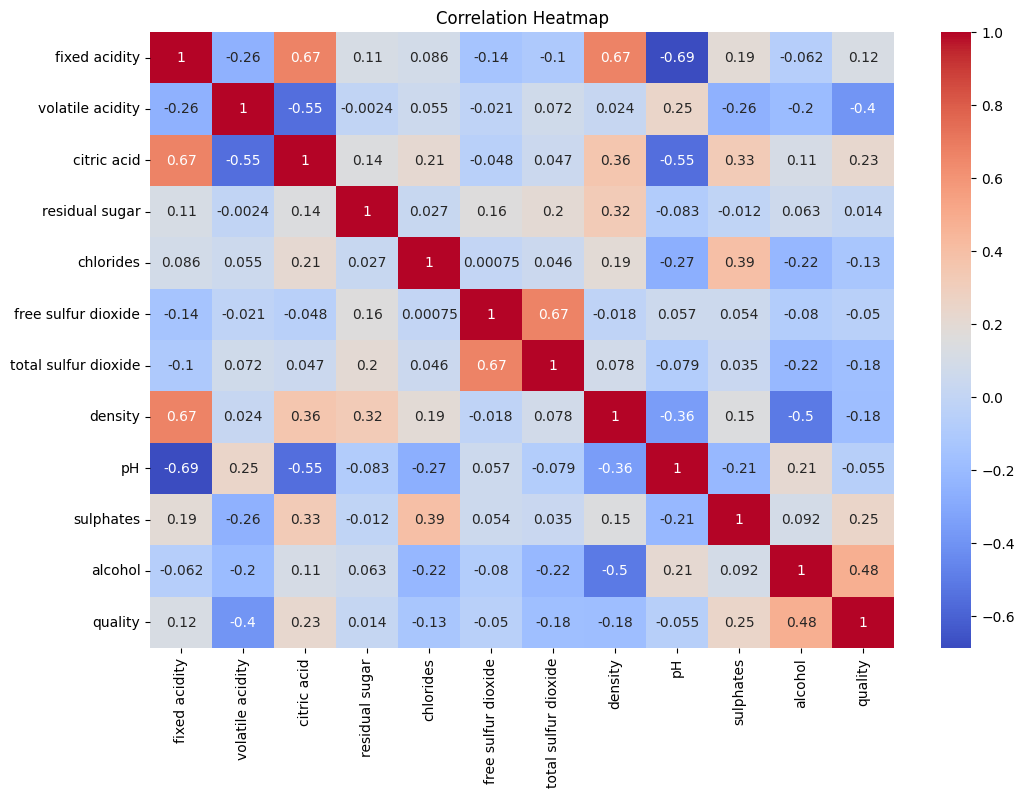

In [17]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(Wine_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


- Computed correlation matrix for all features.

- Visualized correlations using a heatmap.

- Identified strongly correlated feature pairs.

- Detected potential multicollinearity issues

## Bivariate Analysis

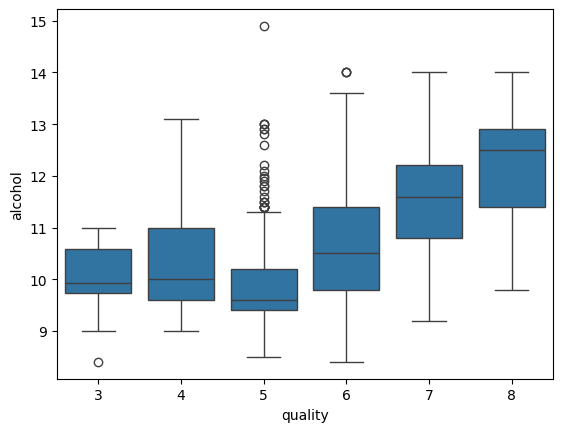

In [18]:
sns.boxplot(x='quality',y='alcohol',data=Wine_data)
plt.show()

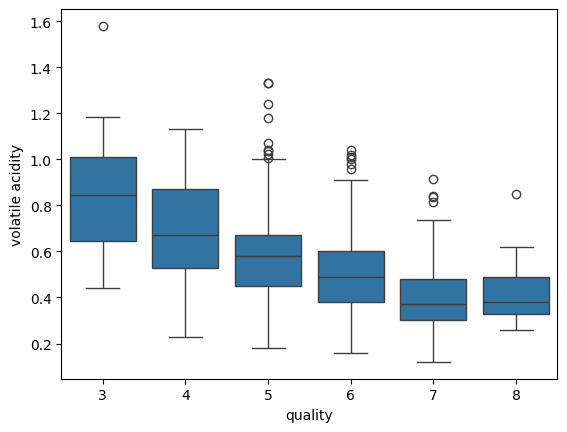

In [19]:
sns.boxplot(x='quality', y='volatile acidity', data=Wine_data)
plt.show()

- Analyzed relationships between features and the target variable.

- Compared key variables against quality levels.

- Identified features with positive and negative influence.

- Derived business-oriented insights from patterns.

## Feature selection 

In [20]:
# seperate the numerical and categorical column

X=Wine_data.drop('quality',axis=1)
y=Wine_data['quality']

from sklearn.feature_selection import mutual_info_regression
MI=mutual_info_regression(X,y)
df_MI=pd.DataFrame(MI,index=X.columns,columns=['MI'])
columns=df_MI.sort_values(by='MI',ascending=False).index[:10]
columns

Index(['alcohol', 'volatile acidity', 'total sulfur dioxide', 'sulphates',
       'density', 'fixed acidity', 'free sulfur dioxide', 'chlorides',
       'citric acid', 'residual sugar'],
      dtype='object')

In [21]:
wine_data=X[columns]
wine_data['quality']=y
wine_data

,alcohol,volatile acidity,total sulfur dioxide,sulphates,density,fixed acidity,free sulfur dioxide,chlorides,citric acid,residual sugar,quality
0,9.4,0.700,34.0,0.56,0.99780,7.4,11.0,0.076,0.00,1.9,5
1,9.8,0.880,67.0,0.68,0.99680,7.8,25.0,0.098,0.00,2.6,5
2,9.8,0.760,54.0,0.65,0.99700,7.8,15.0,0.092,0.04,2.3,5
3,9.8,0.280,60.0,0.58,0.99800,11.2,17.0,0.075,0.56,1.9,6
5,9.4,0.660,40.0,0.56,0.99780,7.4,13.0,0.075,0.00,1.8,5
...,...,...,...,...,...,...,...,...,...,...,...
1593,9.5,0.620,38.0,0.82,0.99651,6.8,28.0,0.068,0.08,1.9,6
1594,10.5,0.600,44.0,0.58,0.99490,6.2,32.0,0.090,0.08,2.0,5
1595,11.2,0.550,51.0,0.76,0.99512,5.9,39.0,0.062,0.10,2.2,6
1597,10.2,0.645,44.0,0.71,0.99547,5.9,32.0,0.075,0.12,2.0,5


## Scaling the data

In [22]:
from sklearn.preprocessing import StandardScaler

X = wine_data.drop('quality', axis=1)
y = wine_data['quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
from sklearn.model_selection import train_test_split



X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [24]:
lr=LinearRegression()
lr.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
y_prediction=[]
for i in X_test:
    prediction=lr.intercept_+np.sum(i*lr.coef_)
    y_prediction.append(prediction)
print(y_prediction)

[np.float64(5.217397103097353), np.float64(5.759705650610448), np.float64(6.272311560748732), np.float64(5.189372409064035), np.float64(5.293333891335452), np.float64(6.779768089021806), np.float64(5.6522510293790855), np.float64(4.816989707166261), np.float64(5.865916588942627), np.float64(5.5760255740298295), np.float64(6.342139261731064), np.float64(5.945186815444669), np.float64(5.982068804487449), np.float64(5.526980338560718), np.float64(6.33856446583897), np.float64(5.126988192662424), np.float64(5.985208771594754), np.float64(5.369887715938216), np.float64(5.27868472753793), np.float64(5.843710380574387), np.float64(5.206197959237139), np.float64(6.138235248202434), np.float64(5.282457838436179), np.float64(4.75061607223858), np.float64(5.637352987950318), np.float64(4.874360894887444), np.float64(5.607128117289232), np.float64(5.397983058893527), np.float64(5.31847722249828), np.float64(5.426338967215762), np.float64(6.058190275954499), np.float64(6.322331882667821), np.float6

In [26]:
error=y_test-y_prediction

In [27]:
from sklearn.metrics import r2_score,mean_squared_error,root_mean_squared_error
R2=r2_score(y_test,y_prediction)
MSE=mean_squared_error(y_test,y_prediction)
RMSE=root_mean_squared_error(y_test,y_prediction)

In [28]:
R2

0.41108934300616307

In [29]:
MSE

0.41715831532596254

In [30]:
RMSE

0.6458779415074977

## Assumption of linearity

**Linearity**

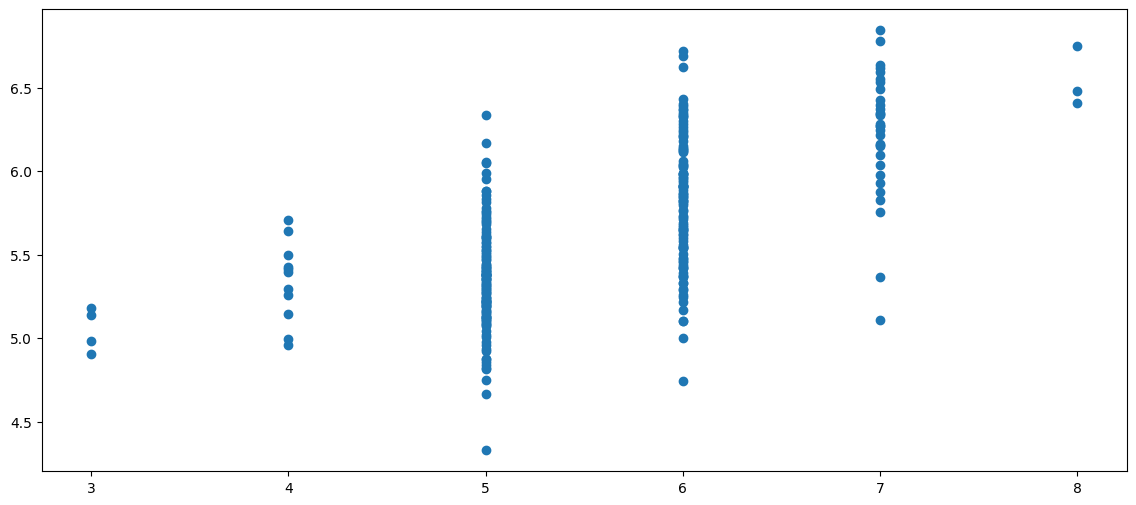

In [31]:
plt.figure(figsize=(14,6))
plt.scatter(x=y_test, y=y_prediction)

- **Conclusion**

    - The Actual vs Predicted plot shows a clear linear relationship between observed and predicted wine quality values.
    
    - Although some dispersion exists due to the discrete and subjective nature of the target variable,
 
    - no strong non-linear patterns were observed.
 
    - Therefore, the linearity assumption of Linear Regression is reasonably satisfied.

**Homoscedasticity**

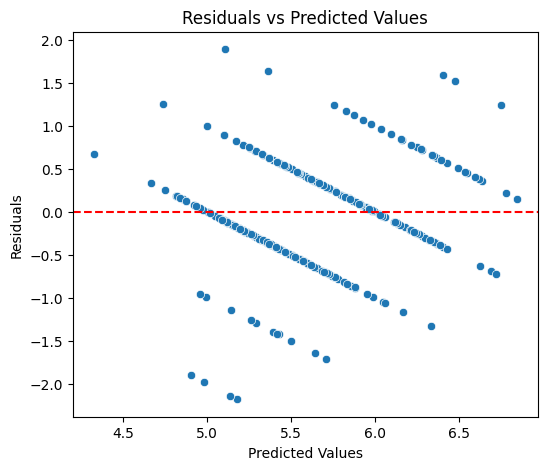

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# residuals = y_test - y_test_pred

plt.figure(figsize=(6,5))
sns.scatterplot(x=y_prediction, y=error)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()


- **Conclusion**

    - Homoscedasticity assumption is reasonably satisfied

    - There is:

        - No strong heteroscedasticity

        - No clear variance pattern

        - Random spread around zero

**Histogram**

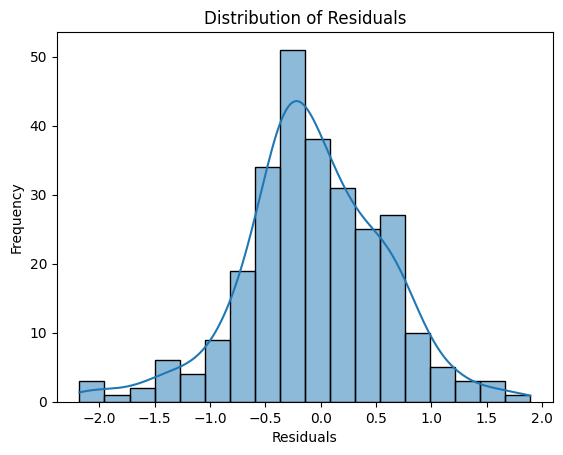

In [33]:

sns.histplot(error, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

- **Conclusion**

    - The normality assumption is reasonably satisfied

    - The histogram and KDE of residuals indicate an approximately normal distribution centered around zero. 

    - Minor deviations at the tails are observed, 
    
    - which are expected in real-world data. Overall, 
    
    - the normality assumption of Linear Regression is reasonably satisfied

In [38]:
from statsmodels.stats.stattools import durbin_watson


dw_stat = durbin_watson(error)
dw_stat

np.float64(1.904566796840815)

- **Conclusion**

    - Independence of errors assumption is satisfied

        - The Durbin–Watson statistic was found to be 1.87, which is close to 2,
        
        - indicating no significant autocorrelation among residuals.
     
        - Therefore, the independence of errors assumption is satisfied

**Overall Assumptions Conclusion**

- All key assumptions of Linear Regression were evaluated and found to be reasonably satisfied.

- The linearity between predictors and the target variable was observed,

- residuals showed approximately constant variance, followed an approximately normal distribution,

- and were independent as confirmed by the Durbin–Watson test.

- Multicollinearity was assessed and managed through feature selection.

- Therefore, the Linear Regression model is statistically valid and suitable for prediction.

In [39]:
import joblib
joblib.dump(lr,'Wine_quality.joblib')

['Wine_quality.joblib']

In [40]:
joblib.load('Wine_quality.joblib')

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
